# RealTrace tutorial

This is a tutorial explaining the usage of RealTrace. Furthermore, it shows how the output can be used for further analysis.

As a an example data set we use a other Machine experiment of cells growing in M9+glucose expressing GFP under the controll of hi1. The data set is also used in the RealTrace paper, but we will only use 100 cell cycles to reduce the total runtime.

This notenbook will 1. setup the files for RealTrace, 2. run RealTrace, and 3. produce some basic plots based on the output. Of course, all terminal commands (starting with '!') can also be run independly of this notebook. 

The notebook makes use of the following helper scripts that can also be used to create customn pipelines:

```
python3 ../RealTrace_toolbox/setup.py [input dir.] [misc. options] [set the bleaching rate] [column settings for reading the input files]

python3 ../RealTrace_toolbox/plot_results.py [input dir.] [misc. options]
```

Notebook tested with: 
```
Pandas version: '1.4.0'
Matplotlib version: '3.5.3'
Numpy verion: '1.26.4'
```


In [1]:
# cleanup of all output files
# ! rm -r Tutorial_data/*_out; rm Tutorial_data/*.txt

<!-- ## Setup -->

### First look at the raw data
Let us first have a look at the input data file to see which column we need to specify, which are plotted below.

In [2]:
import os 
import sys

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl

raw_data = pd.read_csv("Tutorial_data/glucose020_hi1_rawdata.csv")
raw_data

,Unnamed: 0,lane_ID,id,parent_id,time_sec,length_um,gfp_nb
0,0,20190515.0.10,102,94,48960,2.40500,19843.561566
1,1,20190515.0.10,102,94,49140,2.43425,16931.512610
2,2,20190515.0.10,102,94,49320,2.48495,18885.902991
3,3,20190515.0.10,102,94,49500,2.54475,21391.620705
4,4,20190515.0.10,102,94,49680,2.60910,20897.842330
...,...,...,...,...,...,...,...
1970,1970,20190515.0.12,54,43,22320,3.12000,36547.288502
1971,1971,20190515.0.12,54,43,22500,3.18500,38548.873442
1972,1972,20190515.0.12,54,43,22680,3.18500,39169.646560
1973,1973,20190515.0.12,54,43,22860,3.31500,41055.386354


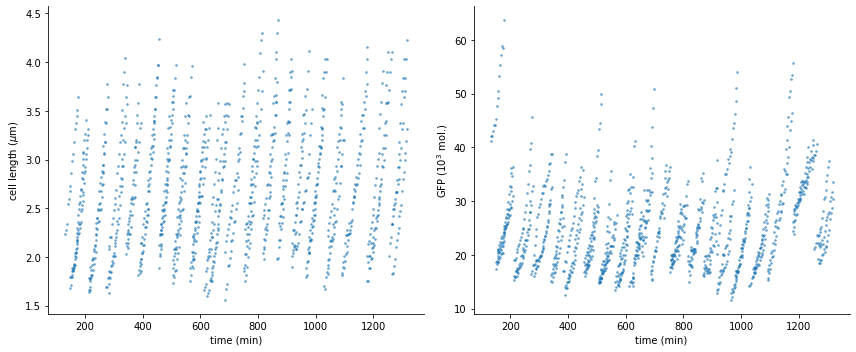

In [3]:
def plot_example_lane(raw_data):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
    ax = axes.ravel()

    for a in ax:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        a.spines['right'].set_color('none')
        a.yaxis.tick_left()

        a.spines['top'].set_color('none')
        a.xaxis.tick_bottom()
        a.set_xlabel("time shift dt (h)")

    example_lane = raw_data[raw_data["lane_ID"]==raw_data["lane_ID"][0]] # Pick the first one as the example lane
    ax[0].scatter(example_lane["time_sec"]/60., example_lane["length_um"], s=3, alpha=0.5)
    ax[0].set_xlabel("time (min)")
    ax[0].set_ylabel("cell length ($\mu$m)")

    ax[1].scatter(example_lane["time_sec"]/60., example_lane["gfp_nb"]/1e3, s=3, alpha=0.5)
    ax[1].set_xlabel("time (min)")
    ax[1].set_ylabel("GFP ($10^3$ mol.)")

    plt.tight_layout()
    plt.show()

plot_example_lane(raw_data)


### Setup the RealTrace run
To run RealTrace we need to write a file with initial parameter guesses and a file that specifies how the input file is read. Both can be done by using the script `setup.py`. Here, we specify the columns that we be read by RealTrace.
Also, we rescale the time to work in minutes rather than seconds (`-rescale_time 60`). The bleaching rate was estimated to be 0.0032 1/min.

In [4]:
! python3 RealTrace_toolbox/setup.py -d Tutorial_data/ -rescale_time 60 -beta 0.0032 -cell_tags lane_ID id -parent_tags lane_ID parent_id -time_col time_sec -length_col length_um -fp_col gfp_nb

1 input files in Tutorial_data/


The parameter file `glucose020_hi1_rawdata_parameters` has the estimates initial values. The initial step is just 10% of the initial values (note that the bleaching rate is fixed). Also, we found that bounds (even very generous ones) helps to prevent numerial issues during the optimization. Therefore, the bounds are initial value/100 and initial values*100. 

The file `csv_config.txt` specifies how the input data should be interpreted.

In [5]:
! echo glucose020_hi1_rawdata_parameters.txt file content:
! cat Tutorial_data/glucose020_hi1_rawdata_parameters.txt
! echo \\ncsv_config.txt file content:
! cat Tutorial_data/csv_config.txt


glucose020_hi1_rawdata_parameters.txt file content:
# Automatically estimated parameter for initialzing MLE search
mean_lambda = 1.17E-02, 1.17E-03, 5.85E-03, 2.34E-02
gamma_lambda = 3.56E-02, 3.56E-03, 3.56E-04, 3.56E+00
var_lambda = 2.44E-06, 2.44E-07, 2.44E-08, 2.44E-04
mean_q = 1.43E+02, 1.43E+01, 7.17E+01, 2.87E+02
gamma_q = 8.89E-02, 8.89E-03, 8.89E-04, 8.89E+00
var_q = 9.13E+02, 9.13E+01, 9.13E+00, 9.13E+04
beta = 3.20E-03
var_x = 3.68E-04, 3.68E-05, 3.68E-06, 3.68E-02
var_g = 3.92E+01, 3.92E+00, 3.92E-01, 3.92E+03
var_dx = 1.00E-03, 1.00E-04
var_dg = 1.00E+00, 1.00E-01

csv_config.txt file content:
# Automatically generated configuration file
time_col = time_sec
length_col = length_um
fp_col = gfp_nb
rescale_time = 6.000E+01
cell_tags = lane_ID, id
parent_tags = lane_ID, parent_id


## Run RealTrace
Now, we can run RealTrace. Check out the RealTrace [wiki](https://github.com/nimwegenLab/RealTrace/wiki/1.-Usage-Overview) for all details. 

We will run all running modes. That is, we first let the parameters be optimized (`-m` flag), calculate the posterior distributions (`-p`), calculate the joint posteriors (`-j`), and sample (`-s`) 10 trajectories (`-n 10`).

Since we did not specify an output file, all output will be saved in the default, which is `Tutorial_data/glucose020_hi1_rawdata_out`.

In [6]:
! ./../bin/RealTrace -c Tutorial_data/csv_config.txt -t 1e-30 -space log -i Tutorial_data/glucose020_hi1_rawdata.csv -b Tutorial_data/glucose020_hi1_rawdata_parameters.txt -m -p -j -s -n 10


Running... 
Temporary log file 'Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata.log' created
Done. Log file: Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_success.log


## Analysis

### Basic plot of cell dynamics
First, we can create a basic plot of the dynamcis predictions a supset of cells. We use the function that is also used in the `plot_results.py` script (which can of course also be run on its own). 

Dots are the original measurements and lines the mean of the posteriors. Shaded regions indicate error bars. 


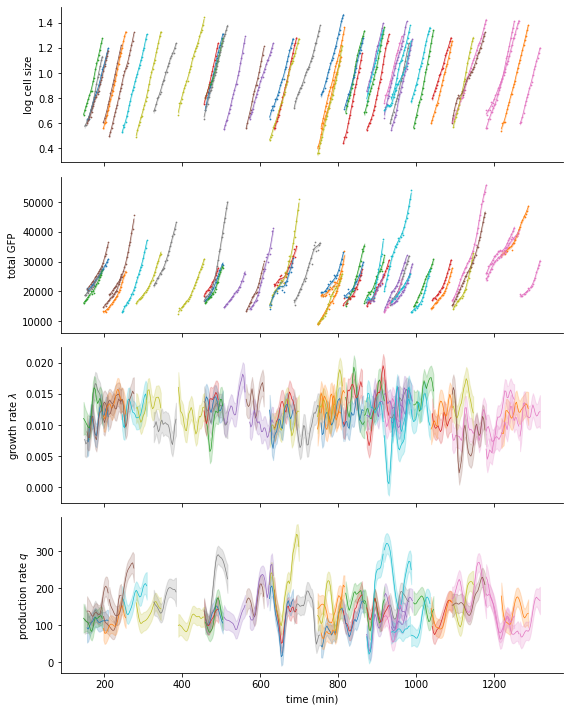

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
      dtype=object)

In [7]:
from RealTrace_toolbox.plot_results import *

plot_predictions("Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_f910_b01234578_prediction.csv", #prediction file 
                n_random_cells=50, # specifies the numer of randomnly chosen cells
                time_unit=('min', 1), # time unit is min
                show=True)

### Correlation functions
Based on the joint posteriors we can calculate correlation functions. The script `correlation_from_joint.py` does this for us. Check out the [readme](https://github.com/nimwegenLab/RealTrace/blob/main/python_src/README_correlation.md) for all details.

Then, we will plot the auto-correlation function of the growth rate and the cross-correlation function between the production and the growth rate.

In [8]:
! python3 ../python_src/correlation_from_joint.py -d Tutorial_data/glucose020_hi1_rawdata_out/ -k glucose020 -dt 3

Tutorial_data/glucose020_hi1_rawdata_out/ is dir
SLURM_JOB_CPUS_PER_NODE unknown, use one 1 core
Saved in Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_f910_b01234578_correlations.csv


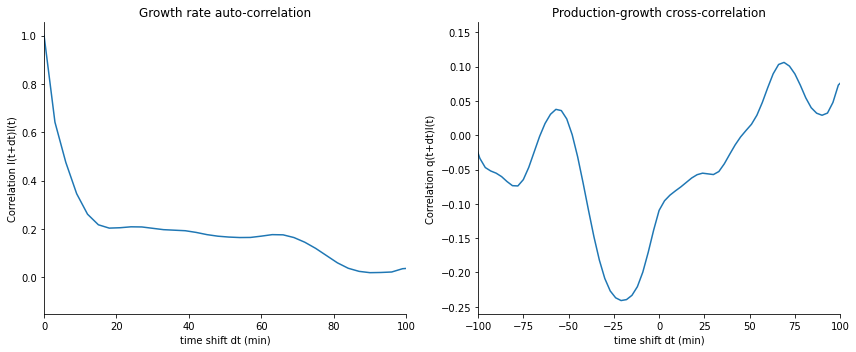

In [9]:
correlations_df = pd.read_csv("Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_f910_b01234578_correlations.csv")

def plot_correlations(correlations_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
    ax = axes.ravel()

    for a in ax:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        a.spines['right'].set_color('none')
        a.yaxis.tick_left()

        a.spines['top'].set_color('none')
        a.xaxis.tick_bottom()
        a.set_xlabel("time shift dt (min)")
        
    # Layout
    ax[0].set_xlim([0,100]) # 100min limit
    ax[1].set_xlim([-100, 100])
    ax[0].set_title("Growth rate auto-correlation")
    ax[1].set_title("Production-growth cross-correlation")

    ax[0].set_ylabel("Correlation l(t+dt)l(t)")
    ax[1].set_ylabel("Correlation q(t+dt)l(t)")

    # Plot the growth rate auto-correlation function
    ax[0].plot(correlations_df["dt"], correlations_df["corr_l(t+dt)l(t)"])

    # Plot the cross-correlation function (joining the two parts together)
    ax[1].plot(np.concatenate([-correlations_df["dt"][::-1], correlations_df["dt"]]), 
               np.concatenate([correlations_df["corr_l(t+dt)q(t)"][::-1], correlations_df["corr_q(t+dt)l(t)"]]))

    plt.tight_layout()

    
plot_correlations(correlations_df)


### Sampled trajectories
Finally, RealTrace also sampled trajectories. First, let us plot a few samples together with the mean of the posterior. Specifically, we plot two cell cycles (of the sample lineage).

We will make use of the functions `df2ggp_cells()` and `df2cells()`, which are defined in the script `RealTrace_toolbox/plot_results.py`. They tranform a pandas data frame with the content into a list of Cells, which is a class containing the relevant variables. 

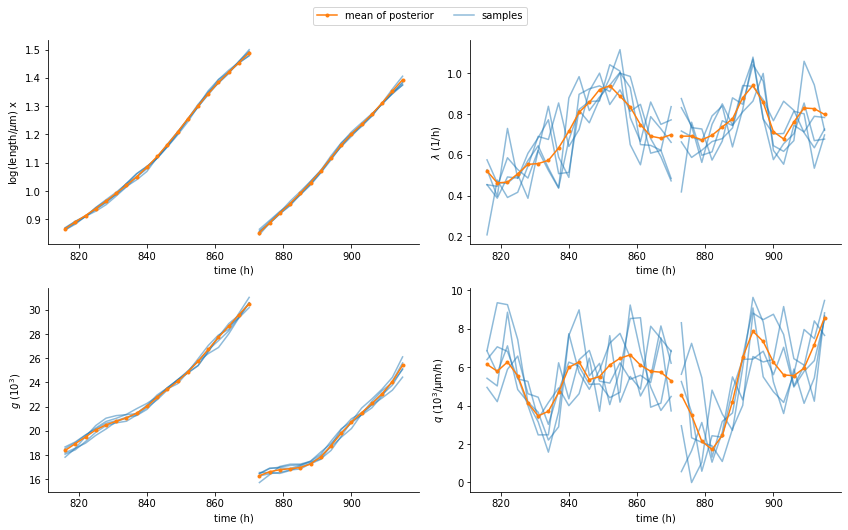

In [35]:

def plot_cell_state_sample(cells_prediction, cell_idx_list, samples, n_samples):
    fig, ax = plt.subplots(2, 2, figsize=(12, 7))
    ax = ax.transpose().ravel()
    for a in ax:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        a.spines['right'].set_color('none')
        a.yaxis.tick_left()

        a.spines['top'].set_color('none')
        a.xaxis.tick_bottom()

        a.set_xlabel("time (h)")

    ax[0].set_ylabel("log(length/$\mu$m) x")  
    ax[1].set_ylabel("$g$ ($10^3$)")   
    ax[2].set_ylabel(r"$\lambda$ (1/h)")   
    ax[3].set_ylabel(r"$q$ $\mathrm{(10^3/\mu m/h)}$") 
    label_p="mean of posterior"
    label_s="samples"

    for cell_idx in cell_idx_list:
        cell_p = cells_prediction[cell_idx]
        ax[0].plot(cell_p.time,  cell_p.mean_x, color="tab:orange", marker=".",label=label_p, zorder=10)
        ax[1].plot(cell_p.time,  np.array(cell_p.mean_g)/1e3, color="tab:orange", marker=".", zorder=10)
        ax[2].plot(cell_p.time,  np.array(cell_p.mean_l)*60, color="tab:orange", marker=".", zorder=10)
        ax[3].plot(cell_p.time,  np.array(cell_p.mean_q)/1e3*60, color="tab:orange", marker=".", zorder=10)
        label_p=None

        for i in range(n_samples):
            cell_s = samples[i][cell_idx]
            ax[0].plot(cell_s.time,  cell_s.x, color="tab:blue", label=label_s, alpha=0.5)
            ax[1].plot(cell_s.time,  np.array(cell_s.g)/1e3, color="tab:blue", alpha=0.5)
            ax[2].plot(cell_s.time,  np.array(cell_s.l)*60, color="tab:blue", alpha=0.5)
            ax[3].plot(cell_s.time,  np.array(cell_s.q)/1e3*60, color="tab:blue", alpha=0.5)
            label_s=None

    fig.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5,1.))
    plt.tight_layout()

    plt.show()


cells_prediction = df2ggp_cells(pd.read_csv("Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_f910_b01234578_prediction.csv", skiprows=12))

samples_dat = pd.read_csv("Tutorial_data/glucose020_hi1_rawdata_out/glucose020_hi1_rawdata_f910_b01234578_samples.csv", skiprows=12)
samples = []
for i in range(10):
    sample_temp = samples_dat[samples_dat["sample"]==i]
    samples.append(df2cells(sample_temp))
    

plot_cell_state_sample(cells_prediction, [0,4], samples, 5)

### Using sampled trajectories to calcuate correlation functions.
We can, for example, use them re-calculate the correlation function above. Of course, the real use is to be able to calculate more involved statistics that can not be calculated from the one time point posteriors. 

A few note about this section:
1. To keep it simple, we will ignore here that the time points are not from a single lineage, but from a tree of cells. Check out the section on correlation function in the paper more details. However, this simplification is a bit inprecise, but it does not matter much here.
2. The code below is simple and is not very efficient (running this section takes around 2min). For large data sets and more specific tasks this is not suitable.


First, we will create a lookup table that saves if two cells belong to the same lineage. Then, we will simply loop over all possible pairs of data points (that belong to the same sample and are part of the same lineage) and collect them accoring to their time difference dt. Afterwards, we calculate the correlation for each dt. 

Finally, we plot the calculated correlation functions with the correlation functions that are based on the joint posteriors. We will see that the correlation functions are (as expected) very close. The correlation functions based on sampled trajectories are noisier, however. This reduces if we were to sample more trajectories.

In [ ]:
# Get all cell paths
def cell_paths(start_cell, cell_list):
    path = [start_cell]
    cell = cell_list[start_cell]
    while cell in cell_list:
        path.append(cell)
        cell = cell_list[cell]
    return path

# Create a lookup table that saves if two cells belong to the same lineage
def paths2matrix(paths, cells):
    lookup = np.zeros(( len(cells),len(cells) ))
    for i, c1 in enumerate(cells):
        for j, c2 in enumerate(cells):
            for path in paths:
                if c1 in path and c2 in path:
                    lookup[i,j] = 1
    return pd.DataFrame(lookup, cells, cells)

def cell_lineage_lookup(cells, parents):
    cell_parent = {}
    parent_cell = {}

    for i, cell in enumerate(cells):
        cell_parent[cell] = parents[i]

    paths = []
    for c in cells:
        if c not in parents:
            paths.append(cell_paths(c, cell_parent))
    return paths2matrix(paths, cells)



# cell_lineage_lookup_table
cell_ids = [cell.cell_id for cell in cells_prediction]
parent_ids = [cell.parent_id for cell in cells_prediction]
cell_lineage_lookup_table = cell_lineage_lookup(cell_ids, parent_ids)



In [ ]:
def get_corr_from_samples(samples_dat, x, y, cell_lineage_lookup_table):
    var_map = {"x":4, "g":5, "l": 6, "q": 7}

    pair_dict = {dt: [] for dt in np.arange(0, 120, 3) }

    for sample in range(np.unique(samples_dat["sample"]).size):
        samples_dat_arr = samples_dat[samples_dat["sample"]==sample].to_numpy()
        n_points = len(samples_dat_arr)
        for i in np.arange(n_points):
            for j in np.arange(i, n_points):
                if cell_lineage_lookup_table[samples_dat_arr[i][0]][samples_dat_arr[j][0]]:
                    dt = np.abs(samples_dat_arr[i][2] - samples_dat_arr[j][2])
                    if dt in pair_dict:
                        pair_dict[dt].append([samples_dat_arr[i][var_map[y]], samples_dat_arr[j][var_map[x]]])

    return pair_dict



ll_corr = get_corr_from_samples(samples_dat, "l", "l", cell_lineage_lookup_table)
ql_corr = get_corr_from_samples(samples_dat, "q", "l", cell_lineage_lookup_table)
lq_corr = get_corr_from_samples(samples_dat, "l", "q", cell_lineage_lookup_table)


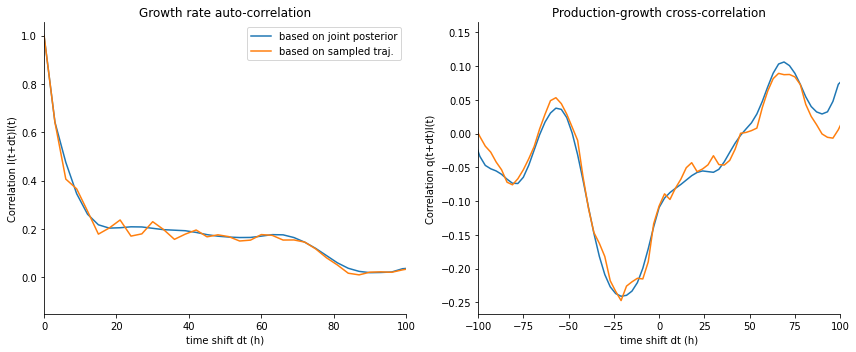

In [ ]:
def plot_comparison_correlations(correlations_df, correlations_from_sampling_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
    ax = axes.ravel()

    for a in ax:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        a.spines['right'].set_color('none')
        a.yaxis.tick_left()

        a.spines['top'].set_color('none')
        a.xaxis.tick_bottom()
        a.set_xlabel("time shift dt (h)")
        
    ax[0].set_xlim([0,100])
    ax[1].set_xlim([-100,100])
    ax[0].set_title("Growth rate auto-correlation")
    ax[1].set_title("Production-growth cross-correlation")

    ax[0].plot(correlations_df["dt"], correlations_df["corr_l(t+dt)l(t)"], label="based on joint posterior")
    ax[0].plot(correlations_from_sampling_df["dt"], correlations_from_sampling_df["corr_l(t+dt)l(t)"], label="based on sampled traj.")

    ax[1].plot(np.concatenate([-correlations_df["dt"][::-1], correlations_df["dt"]]), 
               np.concatenate([correlations_df["corr_l(t+dt)q(t)"][::-1], correlations_df["corr_q(t+dt)l(t)"]]))
    ax[1].plot(np.concatenate([-correlations_from_sampling_df["dt"][::-1], correlations_from_sampling_df["dt"]]), 
               np.concatenate([correlations_from_sampling_df["corr_l(t+dt)q(t)"][::-1], correlations_from_sampling_df["corr_q(t+dt)l(t)"]]))
    
    ax[0].set_ylabel("Correlation l(t+dt)l(t)")
    ax[1].set_ylabel("Correlation q(t+dt)l(t)")
    ax[0].legend()
    plt.tight_layout()

correlations_from_sampling_df = pd.DataFrame({"dt": ll_corr.keys(), 
                                              "corr_l(t+dt)l(t)":[np.corrcoef(np.array(ll_corr[dt])[:,0], np.array(ll_corr[dt])[:,1])[0,1] for dt in ll_corr.keys()],
                                              "corr_q(t+dt)l(t)":[np.corrcoef(np.array(ql_corr[dt])[:,0], np.array(ql_corr[dt])[:,1])[0,1] for dt in ql_corr.keys()],
                                              "corr_l(t+dt)q(t)":[np.corrcoef(np.array(lq_corr[dt])[:,0], np.array(lq_corr[dt])[:,1])[0,1] for dt in lq_corr.keys()]})

plot_comparison_correlations(correlations_df, correlations_from_sampling_df)